In [1]:
import pandas as pd

df = pd.read_csv("stats.csv")
df

,Unnamed: 0,language,script,words,characters,sentences
0,0,afr,Latn,94312386,557347105,5787567
1,1,hau,Latn,106532248,598034693,4991281
2,2,swh,Latn,123031490,786160923,6876752
3,3,amh,Ethi,88455870,455751099,3567387
4,4,som,Latn,128155187,842004417,6311818
5,5,xho,Latn,39110504,351978716,3087046
6,6,yor,Latn,45549046,253040908,1680442
7,7,kin,Latn,53034774,388807641,2848018


In [2]:
df.words.sum()

np.int64(678181505)

In [6]:
df['language_name'] = ['Afrikaans', 'Hausa', 'Swahili', 'Amharic', 'Somali', 'Xhosa', 'Yoruba', 'Kinyarwanda']
df

,Unnamed: 0,language,script,words,characters,sentences,language_name
0,0,afr,Latn,94312386,557347105,5787567,Afrikaans
1,1,hau,Latn,106532248,598034693,4991281,Hausa
2,2,swh,Latn,123031490,786160923,6876752,Swahili
3,3,amh,Ethi,88455870,455751099,3567387,Amharic
4,4,som,Latn,128155187,842004417,6311818,Somali
5,5,xho,Latn,39110504,351978716,3087046,Xhosa
6,6,yor,Latn,45549046,253040908,1680442,Yoruba
7,7,kin,Latn,53034774,388807641,2848018,Kinyarwanda


In [27]:
table = df.copy()

table = table[['language_name', 'language', 'script', 'words', 'characters', 'sentences']]

for c in ['words', 'characters', 'sentences']:
    table[c] = table[c] / 1000000

table = pd.concat([table, pd.DataFrame([
    {'language_name': 'Total', 
     'language': '-', 
     'script': '-', 
     'words': table.words.sum(),
     'characters': table.characters.sum(),
     'sentences': table.sentences.sum(),
     }
])])


table = table.rename(columns={
    'language_name': 'Language',
    'language': 'ISO 639-3 Code',
    'script': 'Script (ISO 15924 Code)',
    'sentences': 'Num sentences [Mio]',
    'characters': 'Num characters [Mio]',
    'words': 'Num words [Mio]'
})

print(table.to_markdown(index=False))

| Language    | ISO 639-3 Code   | Script (ISO 15924 Code)   |   Num words [Mio] |   Num characters [Mio] |   Num sentences [Mio] |
|:------------|:-----------------|:--------------------------|------------------:|-----------------------:|----------------------:|
| Afrikaans   | afr              | Latn                      |           94.3124 |                557.347 |               5.78757 |
| Hausa       | hau              | Latn                      |          106.532  |                598.035 |               4.99128 |
| Swahili     | swh              | Latn                      |          123.031  |                786.161 |               6.87675 |
| Amharic     | amh              | Ethi                      |           88.4559 |                455.751 |               3.56739 |
| Somali      | som              | Latn                      |          128.155  |                842.004 |               6.31182 |
| Xhosa       | xho              | Latn                      |           39.

In [17]:
!pip install tabulate

  Using cached tabulate-0.9.0-py3-none-any.whl.metadata (34 kB)
Using cached tabulate-0.9.0-py3-none-any.whl (35 kB)

[notice] A new release of pip is available: 24.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [3]:
df

,Unnamed: 0,language,script,words,characters,sentences
0,0,afr,Latn,94312386,557347105,5.787567
1,1,hau,Latn,106532248,598034693,4.991281
2,2,swh,Latn,123031490,786160923,6.876752
3,3,amh,Ethi,88455870,455751099,3.567387
4,4,som,Latn,128155187,842004417,6.311818
5,5,xho,Latn,39110504,351978716,3.087046
6,6,yor,Latn,45549046,253040908,1.680442
7,7,kin,Latn,53034774,388807641,2.848018


In [28]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 24.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


Text(0.5, 1.0, 'Dataset size in million words per language')

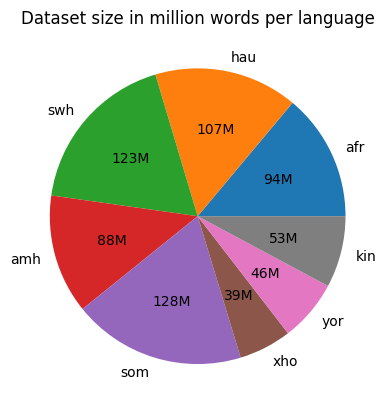

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = df.words
def custom_autopct(pct):
    absolute_value = int(pct/100.*sum(counts)) / 1_000_000
    absolute_value = round(absolute_value)
    return f"{absolute_value}M"

plt.pie(counts, labels=df.language, autopct=custom_autopct)
plt.title("Dataset size in million words per language")


In [ ]:
wget https://mirror.accum.se/mirror/wikimedia.org/dumps/hawiki/20251120/hawiki-20251120-pages-articles.xml.bz2
wget https://mirror.accum.se/mirror/wikimedia.org/dumps/afwiki/20251120/afwiki-20251120-pages-articles.xml.bz2

In [ ]:
python -m wikiextractor.WikiExtractor wikidumps/afwiki-20251120-pages-articles.xml.bz2

afwiki-20251120-pages-articles.xml.bz2
amwiki-20251120-pages-articles.xml.bz2
hawiki-20251120-pages-articles.xml.bz2
rwwiki-20251120-pages-articles.xml.bz2
sowiki-20251120-pages-articles.xml.bz2
swwiki-20251120-pages-articles.xml.bz2
xhwiki-20251120-pages-articles.xml.bz2
yowiki-20251120-pages-articles.xml.bz2


In [4]:
infiles = """afwiki-20251120-pages-articles.xml.bz2
amwiki-20251120-pages-articles.xml.bz2
hawiki-20251120-pages-articles.xml.bz2
rwwiki-20251120-pages-articles.xml.bz2
sowiki-20251120-pages-articles.xml.bz2
swwiki-20251120-pages-articles.xml.bz2
xhwiki-20251120-pages-articles.xml.bz2
yowiki-20251120-pages-articles.xml.bz2""".split("\n")

for f in infiles:
    l = f[0:2]
    c = f'python -m wikiextractor.WikiExtractor wikidumps/{f} -o extractor_output/{l}'
    print(c)

python -m wikiextractor.WikiExtractor wikidumps/afwiki-20251120-pages-articles.xml.bz2 -o extractor_output/af
python -m wikiextractor.WikiExtractor wikidumps/amwiki-20251120-pages-articles.xml.bz2 -o extractor_output/am
python -m wikiextractor.WikiExtractor wikidumps/hawiki-20251120-pages-articles.xml.bz2 -o extractor_output/ha
python -m wikiextractor.WikiExtractor wikidumps/rwwiki-20251120-pages-articles.xml.bz2 -o extractor_output/rw
python -m wikiextractor.WikiExtractor wikidumps/sowiki-20251120-pages-articles.xml.bz2 -o extractor_output/so
python -m wikiextractor.WikiExtractor wikidumps/swwiki-20251120-pages-articles.xml.bz2 -o extractor_output/sw
python -m wikiextractor.WikiExtractor wikidumps/xhwiki-20251120-pages-articles.xml.bz2 -o extractor_output/xh
python -m wikiextractor.WikiExtractor wikidumps/yowiki-20251120-pages-articles.xml.bz2 -o extractor_output/yo


In [6]:
{f[0:2]:'' for f in infiles}

{'af': '',
 'am': '',
 'ha': '',
 'rw': '',
 'so': '',
 'sw': '',
 'xh': '',
 'yo': ''}